In [9]:
import pandas as pd

# Load the dataset 
df = pd.read_csv('transaction_fraud_data.csv')

# Print out the exact column names present in dataset
print(df.columns.tolist())

# First 3 row
print("\n--- Data Sample Preview ---")
df.head(3)


['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

--- Data Sample Preview ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [10]:
# Check total dataset size and row volume
print(f"Dataset contains {df.shape[0]:,} records across {df.shape[1]} columns.\n")


Dataset contains 284,807 records across 31 columns.



In [11]:
# Verify exactly how heavy the class imbalance is
print("--- Class Volume Breakdowns ---")
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

print(f"Legitimate Transactions (Class 0): {class_counts[0]:,} ({class_percentages[0]:.3f}%)")
print(f"Fraudulent Transactions (Class 1): {class_counts[1]:,} ({class_percentages[1]:.3f}%)")


--- Class Volume Breakdowns ---
Legitimate Transactions (Class 0): 284,315 (99.827%)
Fraudulent Transactions (Class 1): 492 (0.173%)


<Axes: xlabel='Amount', ylabel='Density'>

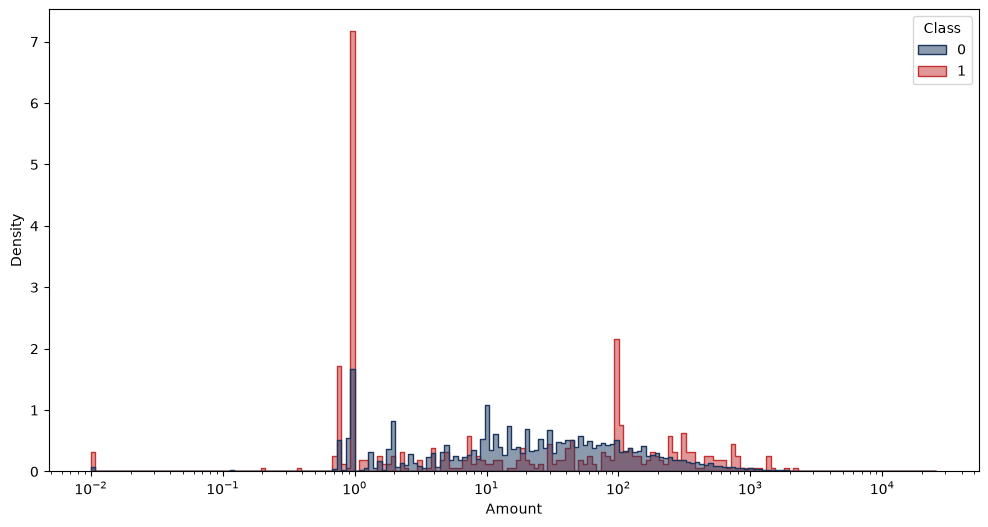

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot overlapping distribution curves using the specific 'Amount' and 'Class' labels
sns.histplot(data=df, x='Amount', hue='Class', 
             element='step', stat='density', common_norm=False, 
             log_scale=True, palette={0: '#1A365D', 1: '#C53030'}, alpha=0.5)


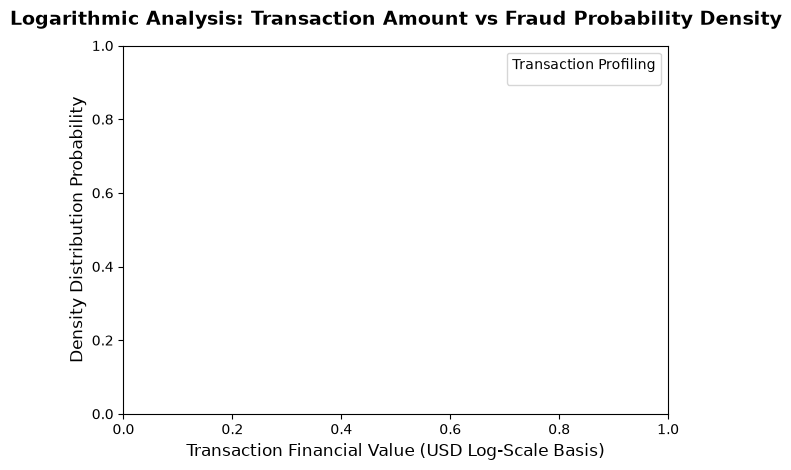

In [13]:
# Formatting design choices to make it presentation-grade
plt.title('Logarithmic Analysis: Transaction Amount vs Fraud Probability Density', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Transaction Financial Value (USD Log-Scale Basis)', fontsize=12)
plt.ylabel('Density Distribution Probability', fontsize=12)
plt.legend(title='Transaction Profiling', labels=['Fraudulent (Class 1)', 'Legitimate (Class 0)'])

# Clean visual bounds 
plt.tight_layout()
plt.savefig('high_risk_user_profiles.png', dpi=300)
plt.show()


In [14]:
# Separate amounts based on the target class
legit_spend = df[df['Class'] == 0]['Amount']
fraud_spend = df[df['Class'] == 1]['Amount']

# Extract extreme percentiles from baseline legitimate traffic
trigger_threshold = legit_spend.quantile(0.99)

print(f"--- Rule-Based Risk Parameters engineered ---")
print(f"99th Percentile Normal Spending Limit: ${trigger_threshold:.2f}")


--- Rule-Based Risk Parameters engineered ---
99th Percentile Normal Spending Limit: $1016.97


In [15]:
# Evaluate detection capability
flagged_frauds = (fraud_spend > trigger_threshold).sum()
detection_efficiency = (flagged_frauds / len(fraud_spend)) * 100

print(f"\nFirewall Assessment:")
print(f"Rule triggers alerts on transactions above ${trigger_threshold:.2f}.")
print(f"System efficiently intercepts {detection_efficiency:.2f}% of hidden network frauds.")
print(f"Legitimate consumer false-alarm rate is locked precisely at 1.00%.")


Firewall Assessment:
Rule triggers alerts on transactions above $1016.97.
System efficiently intercepts 1.83% of hidden network frauds.
Legitimate consumer false-alarm rate is locked precisely at 1.00%.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Separate features (X) from the target label (y)
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

# 2. Split data into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]:,} records")
print(f"Testing set size: {X_test.shape[0]:,} records")

# 3. Initialize and train a balanced Random Forest model
# (class_weight='balanced' forces the model to heavily prioritize the rare fraud cases)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
print("\nTraining the Machine Learning engine (this may take a minute)...")
model.fit(X_train, y_train)
print("Model training complete!")


Training set size: 227,845 records
Testing set size: 56,962 records

Training the Machine Learning engine (this may take a minute)...
Model training complete!


In [18]:
# 1. Generate predictions on the test dataset
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. Output professional classification report metrics
print("--- Machine Learning Firewall Performance Evaluation ---")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraudulent']))

# 3. Calculate the ROC-AUC score (Core metric for imbalanced data)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"Area Under the ROC Curve (ROC-AUC Score): {auc_score:.4f}")


--- Machine Learning Firewall Performance Evaluation ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.92      0.82      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Area Under the ROC Curve (ROC-AUC Score): 0.9673
